# GPT and Autoregressive Models

First inspect shifted targets and one causal forward/backward pass. Then train a tiny causal Transformer on a local sentence corpus, select a validation checkpoint, measure held-out likelihood and perplexity, and generate continuations. This controlled grammar experiment runs on CPU and uses no pretrained weights or downloads.

In [1]:
import torch
from torch import nn

torch.manual_seed(32)
torch.set_num_threads(1)
print('CPU | tiny causal next-token model')

CPU | tiny causal next-token model


In [2]:
vocabulary_size, length, width = 7, 5, 8
tokens = torch.tensor([[1, 2, 3, 4, 5]])
inputs, targets = tokens[:, :-1], tokens[:, 1:]
assert inputs.tolist() == [[1, 2, 3, 4]]
assert targets.tolist() == [[2, 3, 4, 5]]
print('input tokens:', inputs.tolist(), 'next-token targets:', targets.tolist())

input tokens: [[1, 2, 3, 4]] next-token targets: [[2, 3, 4, 5]]


In [3]:
embedding = nn.Embedding(vocabulary_size, width)
position = nn.Embedding(length, width)
layer = nn.TransformerEncoderLayer(d_model=width, nhead=2, dim_feedforward=16,
                                    batch_first=True, dropout=0.0)
backbone = nn.TransformerEncoder(layer, num_layers=1)
head = nn.Linear(width, vocabulary_size)
mask = torch.triu(torch.ones(inputs.shape[1], inputs.shape[1], dtype=torch.bool), diagonal=1)
positions = torch.arange(inputs.shape[1]).unsqueeze(0)
hidden = backbone(embedding(inputs) + position(positions), mask=mask)
logits = head(hidden)
loss = nn.functional.cross_entropy(logits.reshape(-1, vocabulary_size), targets.reshape(-1))
loss.backward()
assert logits.shape == (1, 4, vocabulary_size)
assert torch.isfinite(loss) and embedding.weight.grad is not None
print('logits:', tuple(logits.shape), '| next-token loss:', round(loss.item(), 4))
print('causal mask:')
print(mask.int())

logits: (1, 4, 7) | next-token loss: 1.8157
causal mask:
tensor([[0, 1, 1, 1],
        [0, 0, 1, 1],
        [0, 0, 0, 1],
        [0, 0, 0, 0]], dtype=torch.int32)


The causal mask blocks each position from reading tokens to its right. The real GPT training objective uses very large text datasets and many optimization updates; this tiny example only checks the shifted-target mechanics.

## Complete project: train, select, evaluate, and generate

The earlier cells check one causal loss. This project connects attention (26), Transformer blocks (27), positions (28), heads (29), decoder visibility (30), and the contrast with masked prediction (31). It trains a **small causal Transformer**, not a pretrained GPT.

Our local corpus contains every combination of four colors, animals, actions, and places: 256 distinct sentences. The grammar is deliberately controlled. We split whole sentences before encoding; no sentence appears in two partitions. Held-out combinations test recombination within this grammar, not natural-language understanding. Some choices are inherently unpredictable, so zero next-token loss is not the goal.

| Partition | Sentences | Purpose |
|---|---|---|
| Training | 192 | Learn parameters and vocabulary |
| Validation | 32 | Select the lowest-loss checkpoint |
| Test | 32 | Final likelihood and token accuracy |

All random choices use explicit seeds. The model has learned positions, one pre-normalized attention block, two heads, a feed-forward network, and a vocabulary head. No dropout keeps this small experiment simple.

In [4]:
import itertools, math, copy
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'inline')
import matplotlib.pyplot as plt
import torch.nn.functional as F

torch.manual_seed(320)
colors = ['blue', 'green', 'red', 'yellow']
animals = ['bird', 'cat', 'dog', 'fox']
actions = ['rests', 'runs', 'sits', 'walks']
places = ['garden', 'hill', 'pond', 'tree']
documents = ['the {} {} {} near the {} .'.format(*items)
             for items in itertools.product(colors, animals, actions, places)]
split_rng = torch.Generator().manual_seed(320)
order = torch.randperm(len(documents), generator=split_rng).tolist()
train_docs = [documents[i] for i in order[:192]]
valid_docs = [documents[i] for i in order[192:224]]
test_docs = [documents[i] for i in order[224:]]
assert not (set(train_docs) & set(valid_docs) or set(train_docs) & set(test_docs)
            or set(valid_docs) & set(test_docs))
special = ['<pad>', '<bos>', '<eos>', '<unk>']
word_vocabulary = special + sorted({w for s in train_docs for w in s.split()})
word_to_id = {w: i for i, w in enumerate(word_vocabulary)}
PAD, BOS, EOS, UNK = range(4)

def encode_words(docs):
    rows = [[BOS] + [word_to_id.get(w, UNK) for w in s.split()] + [EOS] for s in docs]
    return nn.utils.rnn.pad_sequence([torch.tensor(row) for row in rows],
                                   batch_first=True, padding_value=PAD)

train_tokens, valid_tokens, test_tokens = map(encode_words, [train_docs, valid_docs, test_docs])
assert (valid_tokens != UNK).all() and (test_tokens != UNK).all()
context_length = train_tokens.shape[1] - 1
print('sentences:', len(train_docs), len(valid_docs), len(test_docs))
print('vocabulary:', len(word_vocabulary), '| input length:', context_length)
print('example:', train_docs[0])

sentences: 192 32 32
vocabulary: 23 | input length: 9
example: the blue bird walks near the hill .


### Causal visibility and padding are separate

Inputs omit the final token; labels omit BOS. An upper-triangular boolean mask blocks future attention. A padding mask blocks nonexistent input positions, while `ignore_index` excludes padded targets from loss. This corpus has equal token lengths, but the code retains these separate contracts. Generation uses the same position convention and stops at EOS or the maximum context length.

In [5]:
class TinyCausalTransformer(nn.Module):
    def __init__(self, vocab_size, max_context, width=32):
        super().__init__()
        self.max_context = max_context
        self.token = nn.Embedding(vocab_size, width, padding_idx=PAD)
        self.position = nn.Embedding(max_context, width)
        self.norm1 = nn.LayerNorm(width)
        self.attention = nn.MultiheadAttention(width, 2, batch_first=True, dropout=0.0)
        self.norm2 = nn.LayerNorm(width)
        self.ffn = nn.Sequential(nn.Linear(width, 64), nn.GELU(), nn.Linear(64, width))
        self.final_norm = nn.LayerNorm(width)
        self.head = nn.Linear(width, vocab_size)

    def forward(self, ids):
        assert 0 < ids.shape[1] <= self.max_context
        positions = torch.arange(ids.shape[1], device=ids.device)
        h = self.token(ids) + self.position(positions)
        causal = torch.triu(torch.ones(ids.shape[1], ids.shape[1], dtype=torch.bool,
                                      device=ids.device), diagonal=1)
        qkv = self.norm1(h)
        attended, _ = self.attention(qkv, qkv, qkv, attn_mask=causal,
                                    key_padding_mask=ids.eq(PAD), need_weights=False)
        h = h + attended
        h = h + self.ffn(self.norm2(h))
        return self.head(self.final_norm(h))

lm = TinyCausalTransformer(len(word_vocabulary), context_length)
assert lm(train_tokens[:2, :-1]).shape == (2, context_length, len(word_vocabulary))
# Alter a future token: predictions strictly before it must remain unchanged.
lm.eval()
with torch.no_grad():
    original = train_tokens[:1, :-1].clone()
    changed = original.clone()
    changed[0, 4] = word_to_id['fox']
    torch.testing.assert_close(lm(original)[:, :4], lm(changed)[:, :4], rtol=1e-5, atol=1e-6)
print('parameters:', sum(p.numel() for p in lm.parameters()), '| causal invariance passed')

parameters: 10391 | causal invariance passed


In [6]:
@torch.no_grad()
def evaluate_words(model, tokens):
    model.eval()
    labels = tokens[:, 1:]
    logits = model(tokens[:, :-1])
    mask = labels.ne(PAD)
    total_loss = F.cross_entropy(logits.reshape(-1, len(word_vocabulary)),
                                 labels.reshape(-1), ignore_index=PAD, reduction='sum')
    nll = (total_loss / mask.sum()).item()
    accuracy = (logits.argmax(-1)[mask] == labels[mask]).float().mean().item()
    return nll, accuracy

optimizer_lm = torch.optim.AdamW(lm.parameters(), lr=0.004, weight_decay=0.01)
word_history = []
best_word_loss, best_word_epoch, best_word_state = float('inf'), None, None
for epoch in range(1, 101):
    lm.train()
    logits = lm(train_tokens[:, :-1])
    loss = F.cross_entropy(logits.reshape(-1, len(word_vocabulary)),
                           train_tokens[:, 1:].reshape(-1), ignore_index=PAD)
    optimizer_lm.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(lm.parameters(), 1.0)
    optimizer_lm.step()
    train_nll, _ = evaluate_words(lm, train_tokens)
    valid_nll, _ = evaluate_words(lm, valid_tokens)
    word_history.append((train_nll, valid_nll))
    if valid_nll < best_word_loss:
        best_word_loss, best_word_epoch = valid_nll, epoch
        best_word_state = copy.deepcopy(lm.state_dict())
assert best_word_state is not None and torch.isfinite(torch.tensor(word_history)).all()
lm.load_state_dict(best_word_state)
print('selected epoch:', best_word_epoch, '| validation NLL:', round(best_word_loss, 4))

selected epoch: 97 | validation NLL: 0.6479


### Compare a frozen model with a training-only baseline

The baseline estimates one next-token distribution from training targets, with additive smoothing. It cannot adapt to the prefix. We exclude PAD and BOS from its candidate distribution. Test loss is averaged over actual target tokens, including EOS. Perplexity is the exponential of this mean loss; token accuracy answers a different question.

Transformer: test NLL=0.6473, perplexity=1.910, accuracy=0.604
Unigram:     test NLL=2.6672, perplexity=14.400, accuracy=0.222


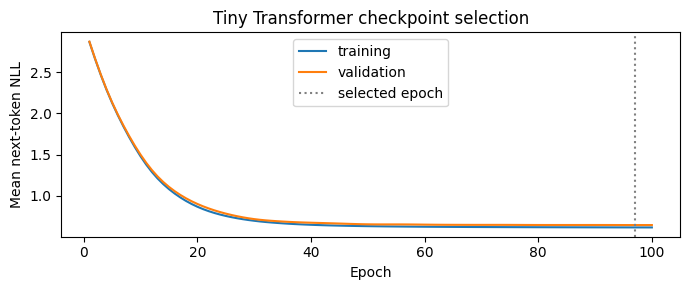

In [7]:
word_counts = torch.bincount(train_tokens[:, 1:].reshape(-1), minlength=len(word_vocabulary)).float()
word_counts += 1.0
word_counts[PAD] = word_counts[BOS] = 0
word_unigram = word_counts / word_counts.sum()
word_test_nll, word_test_accuracy = evaluate_words(lm, test_tokens)
word_test_labels = test_tokens[:, 1:]
word_test_labels = word_test_labels[word_test_labels.ne(PAD)]
word_baseline_nll = -word_unigram[word_test_labels].log().mean().item()
word_baseline_accuracy = (word_test_labels == word_unigram.argmax()).float().mean().item()
print(f'Transformer: test NLL={word_test_nll:.4f}, perplexity={math.exp(word_test_nll):.3f}, accuracy={word_test_accuracy:.3f}')
print(f'Unigram:     test NLL={word_baseline_nll:.4f}, perplexity={math.exp(word_baseline_nll):.3f}, accuracy={word_baseline_accuracy:.3f}')
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(range(1, 101), [r[0] for r in word_history], label='training')
ax.plot(range(1, 101), [r[1] for r in word_history], label='validation')
ax.axvline(best_word_epoch, color='gray', linestyle=':', label='selected epoch')
ax.set(xlabel='Epoch', ylabel='Mean next-token NLL', title='Tiny Transformer checkpoint selection')
ax.legend(); fig.tight_layout(); plt.show()

In [8]:
@torch.no_grad()
def generate_words(prefix='', sample=True, temperature=0.8, seed=321):
    if temperature <= 0:
        raise ValueError('temperature must be positive')
    ids = [BOS] + [word_to_id.get(w, UNK) for w in prefix.split()]
    if UNK in ids or len(ids) > context_length:
        raise ValueError('Use known words and a prefix within the learned position table.')
    generator = torch.Generator().manual_seed(seed)
    lm.eval()
    while len(ids) <= context_length:
        logits = lm(torch.tensor([ids]))[0, -1].clone()
        logits[[PAD, BOS, UNK]] = -float('inf')
        if sample:
            next_id = torch.multinomial((logits / temperature).softmax(-1), 1,
                                        generator=generator).item()
        else:
            next_id = logits.argmax().item()
        ids.append(next_id)
        if next_id == EOS:
            break
    return ' '.join(word_vocabulary[i] for i in ids[1:] if i != EOS)

print('Greedy:', generate_words('the blue', sample=False))
for seed in [321, 322, 323]:
    print('Sample:', generate_words('the', seed=seed))
assert generate_words('the blue', seed=321) == generate_words('the blue', seed=321)
assert len(generate_words('the').split()) <= context_length

Greedy: the blue dog walks near the tree .
Sample: the red dog walks near the tree .
Sample: the yellow cat sits near the tree .
Sample: the yellow dog walks near the hill .


### Interpret the experiment

This is a trained decoder-style Transformer with a disjoint sentence-level holdout, a validation-selected checkpoint, a unigram comparison, and an autoregressive generation loop. The unknown-token policy is explicit, causal invariance is checked, and generated prefixes feed back into prediction. Sampling masks special tokens without imposing the sentence grammar.

The corpus covers a small artificial grammar. Held-out combinations share words and syntax with training; this is useful evidence about recombination, not broad language understanding. Independent word choices prevent perfect predictive certainty. Generated sentences can repeat training combinations, so plausible output alone does not demonstrate novelty. See [character modeling](41_Language_Model_Foundations.ipynb) for a different token unit.
